In [ ]:
# %% 1. Setup and Imports
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch_geometric.nn import GATConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

# --- CONFIGURATION ---
DATASET_FILE = "/content/drive/MyDrive/BWAF-Net-Training/Final_Aligned_Dataset.csv"
GRAPH_FILE = "/content/drive/MyDrive/BWAF-Net-Training/graph_data.pt"
OUTPUT_DIR = "/content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/"
BATCH_SIZE = 16
LR = 0.0005
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Running Ablations on {DEVICE}")

# %% 2. Dataset Class (Updated for Online GAT)
class AblationDataset(Dataset):
    def __init__(self, df, gene_to_idx):
        self.seqs = df['sequence'].values
        self.labels = df['label'].values
        self.gene_idxs = [gene_to_idx.get(g, 0) for g in df['gene_id'].values]
        prior_cols = ["TATA_Box", "CAAT_Box", "GC_Box", "BRE", "MRE", "PPE", "Octamer", "Sp1", "E_Box", "RFX", "CpG_Count"]
        self.priors = np.log1p(df[prior_cols].values.astype(np.float32))
        self.dna_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        seq = [self.dna_map.get(s, 4) for s in self.seqs[i]]
        return (torch.tensor(seq, dtype=torch.long), torch.tensor(self.priors[i], dtype=torch.float32),
                torch.tensor(self.gene_idxs[i], dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.float32))

# %% 3. Model Definitions (Updated)

# A5: Priors Only
class Model_A5(nn.Module):
    def __init__(self, prior_dim=11):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(prior_dim, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, priors, gidx): return self.net(priors)

# A4: Transformer Only
class Model_A4(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.emb = nn.Embedding(5, d_model, padding_idx=4)
        self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2)
        self.clf = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, priors, gidx):
        mask = (seq == 4); x = self.emb(seq) + self.pos
        x = (self.trans(x, src_key_padding_mask=mask) * (~mask).unsqueeze(-1).float()).sum(1) / (~mask).sum(1).clamp(min=1).unsqueeze(-1)
        return self.clf(x.squeeze(1))

# A1: Transformer + Priors
class Model_A1(nn.Module):
    def __init__(self, d_model=64, prior_dim=11):
        super().__init__()
        self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2)
        self.seq_proj = nn.Linear(d_model, 64)
        self.clf = nn.Sequential(nn.Linear(64 + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, seq, priors, gidx):
        mask = (seq == 4); x = self.emb(seq) + self.pos
        h_seq = self.seq_proj((self.trans(x, src_key_padding_mask=mask) * (~mask).unsqueeze(-1).float()).sum(1) / (~mask).sum(1).clamp(min=1).unsqueeze(-1)).squeeze(1)
        return self.clf(torch.cat([h_seq, priors], dim=1))

# A2: GAT + Priors (Online GAT)
class Model_A2(nn.Module):
    def __init__(self, num_nodes, num_feats, d_model=64, prior_dim=11):
        super().__init__()
        self.gat = GATConv(num_feats, d_model, heads=1)
        self.register_buffer('edge_index', None); self.register_buffer('x', None)
        self.clf = nn.Sequential(nn.Linear(d_model + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def set_graph_data(self, x, edge_index): self.x = x; self.edge_index = edge_index
    def forward(self, seq, priors, gidx):
        all_nodes = F.elu(self.gat(self.x, self.edge_index))
        return self.clf(torch.cat([all_nodes[gidx], priors], dim=1))

# A3: Simple Concat (Seq + GAT + Priors)
class Model_A3(nn.Module):
    def __init__(self, num_nodes, num_feats, d_model=64, prior_dim=11):
        super().__init__()
        self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2); self.seq_proj = nn.Linear(d_model, 64)
        self.gat = GATConv(num_feats, d_model, heads=1); self.register_buffer('edge_index', None); self.register_buffer('x', None)
        self.clf = nn.Sequential(nn.Linear(64 + 64 + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def set_graph_data(self, x, edge_index): self.x = x; self.edge_index = edge_index
    def forward(self, seq, priors, gidx):
        mask = (seq == 4); x = self.emb(seq) + self.pos
        h_seq = self.seq_proj((self.trans(x, src_key_padding_mask=mask) * (~mask).unsqueeze(-1).float()).sum(1) / (~mask).sum(1).clamp(min=1).unsqueeze(-1)).squeeze(1)
        h_graph = F.elu(self.gat(self.x, self.edge_index))[gidx]
        return self.clf(torch.cat([h_seq, h_graph, priors], dim=1))

# %% 4. Execution Framework
def run_ablation():
    print("--- 1. LOADING DATA ---")
    df = pd.read_csv(DATASET_FILE)
    graph = torch.load(GRAPH_FILE)

    train_df = df[df['partition'] == 'train']
    val_df = df[df['partition'] == 'val']
    test_df = df[df['partition'] == 'test'] # Rigorous evaluation on Test Set

    train_loader = DataLoader(AblationDataset(train_df, graph['gene_to_idx']), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AblationDataset(val_df, graph['gene_to_idx']), batch_size=BATCH_SIZE)
    test_loader = DataLoader(AblationDataset(test_df, graph['gene_to_idx']), batch_size=BATCH_SIZE)

    num_genes = graph['x'].shape[0]; num_feats = graph['x'].shape[1]

    models = {
        "A5: Priors Only": Model_A5(),
        "A4: Transformer Only": Model_A4(),
        "A1: Transformer+Priors": Model_A1(),
        "A2: GAT+Priors": Model_A2(num_genes, num_feats),
        "A3: Simple Concat": Model_A3(num_genes, num_feats)
    }

    results = []
    roc_data = {}

    for name, model in models.items():
        print(f"\n>>> PROCESSING {name} <<<")
        model = model.to(DEVICE)
        if hasattr(model, 'set_graph_data'): model.set_graph_data(graph['x'].to(DEVICE), graph['edge_index'].to(DEVICE))

        opt = optim.AdamW(model.parameters(), lr=LR)
        crit = nn.BCEWithLogitsLoss()

        train_losses, val_losses = [], []
        best_val = float('inf')

        # Train
        for ep in range(EPOCHS):
            model.train(); ep_loss = 0
            for seq, prior, gidx, y in tqdm(train_loader, desc=f"Ep {ep+1}", leave=False):
                seq, prior, gidx, y = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE), y.to(DEVICE)
                opt.zero_grad(); pred = model(seq, prior, gidx).squeeze(); loss = crit(pred, y)
                loss.backward(); opt.step(); ep_loss += loss.item()
            train_losses.append(ep_loss / len(train_loader))

            # Val
            model.eval(); v_loss = 0
            with torch.no_grad():
                for seq, prior, gidx, y in val_loader:
                    seq, prior, gidx, y = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE), y.to(DEVICE)
                    v_loss += crit(model(seq, prior, gidx).squeeze(), y).item()
            v_loss /= len(val_loader); val_losses.append(v_loss)

            if v_loss < best_val:
                best_val = v_loss; torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"best_{name}.pth"))

        # Plot Loss
        plt.figure(figsize=(6,4)); plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
        plt.title(f'Loss: {name}'); plt.legend(); plt.savefig(os.path.join(OUTPUT_DIR, f"loss_{name}.png")); plt.close()

        # Test Evaluation
        print(f"   Evaluating {name}...")
        model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f"best_{name}.pth")))
        model.eval()
        preds, probs, targs = [], [], []
        with torch.no_grad():
            for seq, prior, gidx, y in test_loader:
                seq, prior, gidx, y = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE), y.to(DEVICE)
                pred = model(seq, prior, gidx).squeeze()
                probs.extend(torch.sigmoid(pred).cpu().numpy())
                targs.extend(y.cpu().numpy())

        preds_bin = np.array(probs) > 0.5
        acc = accuracy_score(targs, preds_bin); auc_val = roc_auc_score(targs, probs)
        f1 = f1_score(targs, preds_bin); prec = precision_score(targs, preds_bin)
        rec = recall_score(targs, preds_bin); tn, fp, fn, tp = confusion_matrix(targs, preds_bin).ravel(); spec = tn/(tn+fp)

        print(f"   RESULT: Acc={acc:.4f}, AUC={auc_val:.4f}")
        results.append({'Model': name, 'Accuracy': acc, 'AUC': auc_val, 'F1': f1, 'Precision': prec, 'Recall': rec, 'Specificity': spec})

        # Save CM
        cm = confusion_matrix(targs, preds_bin); plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'CM: {name}'); plt.savefig(os.path.join(OUTPUT_DIR, f"cm_{name}.png")); plt.close()

        roc_data[name] = (targs, probs)

    # --- FINAL SUMMARY ---
    print("\n================ FINAL SUMMARY ================")
    res_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
    print(res_df.to_string(index=False))
    res_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_metrics.csv"), index=False)

    # Combined ROC
    plt.figure(figsize=(8, 6))
    for name, (y, p) in roc_data.items():
        fpr, tpr, _ = roc_curve(y, p); roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.2f})')
    plt.plot([0,1],[0,1], linestyle='--', color='gray'); plt.legend(loc='lower right')
    plt.title('Ablation ROC Curves'); plt.savefig(os.path.join(OUTPUT_DIR, "combined_roc.png")); plt.show()

if __name__ == "__main__":
    run_ablation()

Running Ablations on cuda
--- 1. LOADING DATA ---

>>> PROCESSING A5: Priors Only <<<


Ep 1:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 2:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 3:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 4:   0%|          | 0/1487 [00:00<?, ?it/s]

...

   Evaluating A2: GAT+Priors...
   RESULT: Acc=0.7473, AUC=0.8285

>>> PROCESSING A3: Simple Concat <<<


Ep 1:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 2:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 3:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 4:   0%|          | 0/1487 [00:00<?, ?it/s]

--- RUNNING ABLATION STUDY (STRICT RESUME FIXED) ON cuda ---
--- 1. LOADING DATA ---

>>> PROCESSING A5: Priors Only <<<
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/best_A5_Priors_Only.pth
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/loss_A5_Priors_Only.png
   ✅ Found complete run (Model + Plots). Skipping Training.
   Evaluating A5_Priors_Only...
   RESULT: Acc=0.7517, AUC=0.8332

>>> PROCESSING A4: Transformer Only <<<
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/best_A4_Transformer_Only.pth
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/loss_A4_Transformer_Only.png
   ✅ Found complete run (Model + Plots). Skipping Training.
   Evaluating A4_Transformer_Only...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


   RESULT: Acc=0.5724, AUC=0.6022

>>> PROCESSING A1: Transformer+Priors <<<
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/best_A1_Transformer+Priors.pth
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/loss_A1_Transformer+Priors.png
   ✅ Found complete run (Model + Plots). Skipping Training.
   Evaluating A1_Transformer+Priors...
   RESULT: Acc=0.8023, AUC=0.8852

>>> PROCESSING A2: GAT+Priors <<<
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/best_A2_GAT+Priors.pth
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/loss_A2_GAT+Priors.png
   ✅ Found complete run (Model + Plots). Skipping Training.
   Evaluating A2_GAT+Priors...
   RESULT: Acc=0.7473, AUC=0.8285

>>> PROCESSING A3: Simple Concat <<<
   Checking for: /content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/best_A3_Simple_Concat.pth
   Checking for: /content/drive/MyDrive/BWAF-Net

Ep 1:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 1: Train 0.5816 | Val 0.5308


...

Ep 8: Train 0.4848 | Val 0.4725


Ep 9:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 9: Train 0.4822 | Val 0.4726


Ep 10:   0%|          | 0/1487 [00:00<?, ?it/s]

Ep 10: Train 0.4722 | Val 0.4916
   Evaluating A3_Simple_Concat...
   RESULT: Acc=0.7724, AUC=0.8494

================ FINAL SUMMARY ================
                 Model  Accuracy      AUC       F1  Precision   Recall  Specificity
A1: Transformer+Priors  0.802269 0.885228 0.788781   0.846525 0.738412     0.866126
     A3: Simple Concat  0.772447 0.849424 0.768011   0.783283 0.753323     0.791572
       A5: Priors Only  0.751702 0.833200 0.744496   0.766747 0.723501     0.779903
        A2: GAT+Priors  0.747326 0.828480 0.736433   0.769611 0.705997     0.788655
  A4: Transformer Only  0.572447 0.602188 0.607440   0.561486 0.661588     0.483306


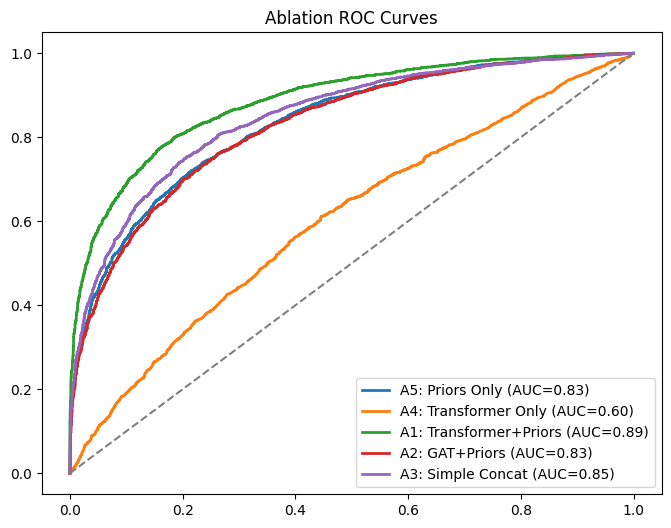

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_FILE = "/content/drive/MyDrive/BWAF-Net-Training/Final_Aligned_Dataset.csv"
GRAPH_FILE = "/content/drive/MyDrive/BWAF-Net-Training/graph_data.pt"
OUTPUT_DIR = "/content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/"
BATCH_SIZE = 16
LR = 0.0005
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"--- RUNNING ABLATION STUDY (STRICT RESUME FIXED) ON {DEVICE} ---")

# ==========================================
# 2. DATASET & MODELS
# ==========================================
class AblationDataset(Dataset):
    def __init__(self, df, gene_to_idx):
        self.seqs = df['sequence'].values
        self.labels = df['label'].values
        self.gene_idxs = [gene_to_idx.get(g, 0) for g in df['gene_id'].values]
        prior_cols = ["TATA_Box", "CAAT_Box", "GC_Box", "BRE", "MRE", "PPE",
                      "Octamer", "Sp1", "E_Box", "RFX", "CpG_Count"]
        self.priors = np.log1p(df[prior_cols].values.astype(np.float32))
        self.dna_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        seq = [self.dna_map.get(s, 4) for s in self.seqs[i]]
        return (torch.tensor(seq, dtype=torch.long), torch.tensor(self.priors[i], dtype=torch.float32),
                torch.tensor(self.gene_idxs[i], dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.float32))

class Model_A5(nn.Module):
    def __init__(self, prior_dim=11):
        super().__init__(); self.net = nn.Sequential(nn.Linear(prior_dim, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, priors, gidx): return self.net(priors)

class Model_A4(nn.Module):
    def __init__(self, d_model=64):
        super().__init__(); self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2); self.clf = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, priors, gidx):
        mask = (seq == 4); x = self.emb(seq) + self.pos
        x = (self.trans(x, src_key_padding_mask=mask) * (~mask).unsqueeze(-1).float()).sum(1) / (~mask).sum(1).clamp(min=1).unsqueeze(-1)
        return self.clf(x.squeeze(1))

class Model_A1(nn.Module):
    def __init__(self, d_model=64, prior_dim=11):
        super().__init__(); self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2); self.seq_proj = nn.Linear(d_model, 64)
        self.clf = nn.Sequential(nn.Linear(64 + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, seq, priors, gidx):
        mask = (seq == 4); x = self.emb(seq) + self.pos
        h_seq = self.seq_proj((self.trans(x, src_key_padding_mask=mask) * (~mask).unsqueeze(-1).float()).sum(1) / (~mask).sum(1).clamp(min=1).unsqueeze(-1)).squeeze(1)
        return self.clf(torch.cat([h_seq, priors], dim=1))

class Model_A2(nn.Module):
    def __init__(self, num_nodes, num_feats, d_model=64, prior_dim=11):
        super().__init__(); self.gat = GATConv(num_feats, d_model, heads=1); self.register_buffer('edge_index', None); self.register_buffer('x', None)
        self.clf = nn.Sequential(nn.Linear(d_model + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def set_graph_data(self, x, edge_index): self.x = x; self.edge_index = edge_index
    def forward(self, seq, priors, gidx): return self.clf(torch.cat([F.elu(self.gat(self.x, self.edge_index))[gidx], priors], dim=1))

class Model_A3(nn.Module):
    def __init__(self, num_nodes, num_feats, d_model=64, prior_dim=11):
        super().__init__(); self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2); self.seq_proj = nn.Linear(d_model, 64)
        self.gat = GATConv(num_feats, d_model, heads=1); self.register_buffer('edge_index', None); self.register_buffer('x', None)
        self.clf = nn.Sequential(nn.Linear(64 + 64 + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def set_graph_data(self, x, edge_index): self.x = x; self.edge_index = edge_index
    def forward(self, seq, priors, gidx):
        mask = (seq == 4); x = self.emb(seq) + self.pos
        h_seq = self.seq_proj((self.trans(x, src_key_padding_mask=mask) * (~mask).unsqueeze(-1).float()).sum(1) / (~mask).sum(1).clamp(min=1).unsqueeze(-1)).squeeze(1)
        h_graph = F.elu(self.gat(self.x, self.edge_index))[gidx]
        return self.clf(torch.cat([h_seq, h_graph, priors], dim=1))

# ==========================================
# 3. UTILS
# ==========================================
def plot_loss(train_losses, val_losses, name):
    plt.figure(figsize=(6,4)); plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
    plt.title(f'Loss: {name}'); plt.legend(); plt.savefig(os.path.join(OUTPUT_DIR, f"loss_{name}.png")); plt.close()

def plot_cm(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred); plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'CM: {name}'); plt.savefig(os.path.join(OUTPUT_DIR, f"cm_{name}.png")); plt.close()

# ==========================================
# 4. MAIN LOOP
# ==========================================
def run_ablation():
    print("--- 1. LOADING DATA ---")
    df = pd.read_csv(DATASET_FILE)
    graph = torch.load(GRAPH_FILE)

    train_df = df[df['partition'] == 'train']
    val_df = df[df['partition'] == 'val']
    test_df = df[df['partition'] == 'test']

    train_loader = DataLoader(AblationDataset(train_df, graph['gene_to_idx']), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AblationDataset(val_df, graph['gene_to_idx']), batch_size=BATCH_SIZE)
    test_loader = DataLoader(AblationDataset(test_df, graph['gene_to_idx']), batch_size=BATCH_SIZE)

    num_genes = graph['x'].shape[0]; num_feats = graph['x'].shape[1]

    models = {
        "A5: Priors Only": Model_A5(),
        "A4: Transformer Only": Model_A4(),
        "A1: Transformer+Priors": Model_A1(),
        "A2: GAT+Priors": Model_A2(num_genes, num_feats),
        "A3: Simple Concat": Model_A3(num_genes, num_feats)
    }

    results = []
    roc_data = {}

    for name, model in models.items():
        print(f"\n>>> PROCESSING {name} <<<")
        model = model.to(DEVICE)

        # Consistent filename format (Sanitized)
        safe_name = name.replace(' ', '_').replace(':', '')
        model_path = os.path.join(OUTPUT_DIR, f"best_{safe_name}.pth")
        plot_path = os.path.join(OUTPUT_DIR, f"loss_{safe_name}.png")

        if hasattr(model, 'set_graph_data'):
            model.set_graph_data(graph['x'].to(DEVICE), graph['edge_index'].to(DEVICE))

        opt = optim.AdamW(model.parameters(), lr=LR)
        crit = nn.BCEWithLogitsLoss()

        # --- RESUME LOGIC (STRICT) ---
        print(f"   Checking for: {model_path}")
        print(f"   Checking for: {plot_path}")

        if os.path.exists(model_path) and os.path.exists(plot_path):
            print(f"   ✅ Found complete run (Model + Plots). Skipping Training.")
        else:
            print(f"   ⚠️ Files missing. Training from scratch...")
            # --- THE FIX IS HERE: Initialize lists correctly ---
            train_losses = []
            val_losses = []
            best_val = float('inf')

            for ep in range(EPOCHS):
                model.train(); ep_loss = 0
                for seq, prior, gidx, y in tqdm(train_loader, desc=f"Ep {ep+1}", leave=False):
                    seq, prior, gidx, y = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE), y.to(DEVICE)
                    opt.zero_grad(); pred = model(seq, prior, gidx).squeeze(); loss = crit(pred, y)
                    loss.backward(); opt.step(); ep_loss += loss.item()
                train_losses.append(ep_loss / len(train_loader))

                model.eval(); v_loss = 0
                with torch.no_grad():
                    for seq, prior, gidx, y in val_loader:
                        seq, prior, gidx, y = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE), y.to(DEVICE)
                        v_loss += crit(model(seq, prior, gidx).squeeze(), y).item()
                v_loss /= len(val_loader); val_losses.append(v_loss)

                if v_loss < best_val:
                    best_val = v_loss
                    torch.save(model.state_dict(), model_path)
                print(f"Ep {ep+1}: Train {train_losses[-1]:.4f} | Val {v_loss:.4f}")

            plot_loss(train_losses, val_losses, safe_name)

        # --- EVALUATION ---
        print(f"   Evaluating {safe_name}...")
        try:
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        except Exception as e:
            print(f"   ❌ Critical: Could not load model for {name}. Error: {e}")
            print(f"   Skipping evaluation for this model.")
            continue

        model.eval()
        preds, probs, targs = [], [], []
        with torch.no_grad():
            for seq, prior, gidx, y in test_loader:
                seq, prior, gidx, y = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE), y.to(DEVICE)
                pred = model(seq, prior, gidx).squeeze()
                prob = torch.sigmoid(pred)

                preds.extend((prob > 0.5).float().cpu().numpy())
                probs.extend(prob.cpu().numpy())
                targs.extend(y.cpu().numpy())

        acc = accuracy_score(targs, preds); auc_val = roc_auc_score(targs, probs)
        f1 = f1_score(targs, preds); prec = precision_score(targs, preds)
        rec = recall_score(targs, preds); tn, fp, fn, tp = confusion_matrix(targs, preds).ravel(); spec = tn/(tn+fp)

        print(f"   RESULT: Acc={acc:.4f}, AUC={auc_val:.4f}")
        results.append({'Model': name, 'Accuracy': acc, 'AUC': auc_val, 'F1': f1, 'Precision': prec, 'Recall': rec, 'Specificity': spec})
        plot_cm(targs, preds, safe_name)
        roc_data[name] = (targs, probs)

    # --- FINAL OUTPUT ---
    print("\n================ FINAL SUMMARY ================")
    if results:
        res_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
        print(res_df.to_string(index=False))
        res_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_metrics.csv"), index=False)

        # Combined ROC
        plt.figure(figsize=(8, 6))
        for name, (y, p) in roc_data.items():
            fpr, tpr, _ = roc_curve(y, p); roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.2f})')
        plt.plot([0,1],[0,1], linestyle='--', color='gray'); plt.legend(loc='lower right')
        plt.title('Ablation ROC Curves'); plt.savefig(os.path.join(OUTPUT_DIR, "combined_roc.png")); plt.show()
    else:
        print("No results generated.")

if __name__ == "__main__":
    run_ablation()